In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv(
    r"H:\WGUData\D213\sentiment labelled sentences\amazon_cells_labelled.txt",   # (Kotzias et al., 2015)
    sep="\t",
    header=None,
    names=["review", "sentiment"]
)

df.head()

,review,sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [3]:
print(df.shape)
print(df.info())

(1000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     1000 non-null   object
 1   sentiment  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None


A1. Research Question

The research question for this analysis is: Can a neural network using natural language processing (NLP) accurately classify customer review sentiment in order to help organizations automatically identify negative customer feedback and improve response time to customer concerns?

A2. Goals of the Data Analysis

The goal of this analysis is to develop a neural network model that can automatically classify customer review text as either positive or negative sentiment in order to support faster and more efficient customer feedback analysis.

Organizations frequently collect customer feedback through product reviews, surveys, and service interactions. Because these sources often generate large volumes of unstructured text, manually reviewing each customer comment is inefficient and difficult to scale. The purpose of this analysis is to demonstrate how neural networks and NLP techniques can be used to automate this process and provide organizations with faster insight into customer sentiment.

A3. Neural Network Type

The neural network selected for this analysis is a Long Short-Term Memory (LSTM) neural network, which is a type of recurrent neural network (RNN) designed for sequential data such as text.

An LSTM network is well suited for this analysis because customer reviews are composed of ordered word sequences, and the meaning of a sentence often depends on the context created by the arrangement of those words. In sentiment analysis, word order is important because the same words can convey different meanings depending on how they are used in a sentence. For example, phrases such as “not good” and “very good” contain similar words but communicate different sentiment due to word sequence and context. (GeeksforGeeks, 2019)

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows:
10


In [5]:
df = df.drop_duplicates()

In [6]:
# Function to find unusual/non-standard characters
def find_unusual_characters(text):
    return re.findall(r"[^a-zA-Z0-9\s.,!?'\-]", text)

df["unusual_characters"] = df["review"].apply(find_unusual_characters)

# Count rows with unusual characters
rows_with_unusual = df[df["unusual_characters"].apply(len) > 0]

print("Number of rows with unusual characters:", len(rows_with_unusual))
rows_with_unusual[["review", "unusual_characters"]].head(10)

Number of rows with unusual characters: 70


,review,unusual_characters
12,If the two were seperated by a mere 5+ ft I st...,[+]
14,"The design is very odd, as the ear ""clip"" is n...","["", ""]"
25,Great Pocket PC / phone combination.,[/]
69,This device is great in several situations:1.),"[:, )]"
98,Best I've found so far .... I've tried 2 other...,"[(, )]"
105,"Pros:-Good camera - very nice pictures , also ...",[:]
106,That's a huge design flaw (unless I'm not usin...,"[(, )]"
119,)Setup couldn't have been simpler.,[)]
132,Headset works great & was packaged nicely to a...,[&]
154,I've bought $5 wired headphones that sound bet...,[$]


In [7]:
# Count words in each review
df["word_count"] = df["review"].apply(lambda x: len(x.split()))

# Summary statistics
df["word_count"].describe()

count    990.000000
mean      10.305051
std        6.680932
min        1.000000
25%        5.000000
50%        9.000000
75%       15.000000
max       30.000000
Name: word_count, dtype: float64

In [8]:
max_sequence_length = int(np.percentile(df["word_count"], 95))

print("95th percentile sequence length:", max_sequence_length)

95th percentile sequence length: 23


In [9]:
# Clean and split words for vocabulary estimate
all_words = " ".join(df["review"].str.lower()).split()
vocab = set(all_words)

vocab_size_estimate = len(vocab)

print("Estimated vocabulary size:", vocab_size_estimate)

Estimated vocabulary size: 2514


In [10]:
embedding_dim = 16
print("Proposed embedding length:", embedding_dim)

Proposed embedding length: 16


B1. Exploratory Data Analysis

Exploratory data analysis was conducted on the Amazon review data set to evaluate data quality and key text characteristics before preparing the data for neural network modeling. The original data set contained 1,000 review records and 2 variables: review text and sentiment label. The sentiment classes were balanced, with 500 negative and 500 positive reviews.

No missing values were identified. However, 10 duplicate review records were found and removed to reduce redundancy and prevent repeated review text from biasing model performance, leaving 990 unique observations for analysis.

The review text was examined for unusual characters, and 70 rows contained non-standard symbols or punctuation. These rows were retained because the review text remained usable, and unusual characters were handled later during text normalization and tokenization.

The estimated vocabulary size was 2,514 unique words. The proposed embedding length was set to 16, which is appropriate for a relatively small vocabulary and short review text.

Review length was measured by word count. The average review length was 10.31 words, with a minimum of 1 word and a maximum of 30 words. The maximum sequence length was set to 23 words based on the 95th percentile of review lengths, which preserves most review content while limiting unnecessary padding.

In [11]:
# Text normalization function, convert to lowercase, remove punctuation/special characters
def clean_text(text):
    text = text.lower()                         
    text = re.sub(r"[^a-z0-9\s]", "", text)     
    return text

# Apply text cleaning
df["clean_review"] = df["review"].apply(clean_text)

# Preview cleaned text
df[["review", "clean_review"]].head()

,review,clean_review
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great for the jawbone
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...
4,The mic is great.,the mic is great


In [12]:
# Initialize tokenizer
tokenizer = Tokenizer()

# Fit tokenizer on cleaned review text
tokenizer.fit_on_texts(df["clean_review"])

# Convert text to integer sequences
sequences = tokenizer.texts_to_sequences(df["clean_review"])

# Preview tokenized sequence
print("Original review:")
print(df["clean_review"].iloc[0])

print("\nTokenized sequence:")
print(sequences[0])

Original review:
so there is no way for me to plug it in here in the us unless i go by a converter

Tokenized sequence:
[33, 116, 5, 56, 210, 11, 49, 8, 152, 4, 19, 330, 19, 1, 538, 539, 2, 236, 185, 6, 789]


In [13]:
# Store vocabulary size for model use
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size after tokenization:", vocab_size)

Vocabulary size after tokenization: 1906


B2. Tokenization Process

Tokenization was used to convert customer review text into a numerical format that could be processed by the neural network. Because neural networks cannot interpret raw text directly, each review first had to be normalized and transformed into sequences of integers representing individual words.

Text normalization was performed prior to tokenization to standardize the review text and reduce noise in the input data. This process included converting all review text to lowercase and removing punctuation and non-alphanumeric characters using the re package. Lowercasing ensured that words such as “Good” and “good” were treated as the same token, while removing punctuation reduced unnecessary variation in the text.

After normalization, the Tokenizer class from TensorFlow Keras was used to assign each unique word in the review corpus a numerical index based on vocabulary frequency. The tokenizer was then used to convert each cleaned review into a sequence of integers, where each integer represents a specific word token. After tokenization, the final vocabulary size was 1,906 unique tokens.

The goal of tokenization was to transform unstructured customer review text into a structured numerical format while preserving word order. This allows the neural network to evaluate word usage patterns and contextual relationships in the review text during model training.

In [14]:
# Set maximum sequence length based on 95th percentile from B1
max_length = 23

# Pad sequences so all reviews have the same length
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Display one original sequence and its padded version
print("Original tokenized sequence:")
print(sequences[0])

print("\nPadded sequence:")
print(padded_sequences[0])

print("\nLength of padded sequence:")
print(len(padded_sequences[0]))

Original tokenized sequence:
[33, 116, 5, 56, 210, 11, 49, 8, 152, 4, 19, 330, 19, 1, 538, 539, 2, 236, 185, 6, 789]

Padded sequence:
[ 33 116   5  56 210  11  49   8 152   4  19 330  19   1 538 539   2 236
 185   6 789   0   0]

Length of padded sequence:
23


In [15]:
# Single padded sequence for screenshot
padded_sequences[0]

array([ 33, 116,   5,  56, 210,  11,  49,   8, 152,   4,  19, 330,  19,
         1, 538, 539,   2, 236, 185,   6, 789,   0,   0], dtype=int32)

B3. Padding Process

Padding was used to standardize all tokenized review sequences to the same length before they were entered into the neural network. Because customer reviews vary in length, padding is necessary to ensure that all input sequences have a consistent size for model training.

The maximum sequence length was set to 23 words, based on the 95th percentile of review lengths identified during exploratory data analysis. Padding was applied after each sequence using post-padding, which added zeros to the end of review sequences shorter than 23 tokens. Reviews longer than 23 tokens were truncated after the 23rd token.

Post-padding was selected because it preserves the original word order at the beginning of each review while adding zeros only after the meaningful text. This allowed each review to be represented as a standardized sequence of 23 numerical values for input into the neural network.

B4. Sentiment Categories and Output Activation Function

This analysis used two sentiment categories for classification: positive and negative. These categories were represented using binary labels, where 0 indicated negative sentiment and 1 indicated positive sentiment. Binary sentiment classification is a common approach in sentiment analysis when the objective is to determine whether text reflects favorable or unfavorable customer opinion. (Zou & Xiang, 2022)

Because the target variable contains only two possible outcomes, the output layer of the neural network used a single node with a sigmoid activation function. The sigmoid activation function was selected because it is appropriate for binary classification tasks and produces an output value between 0 and 1, which can be interpreted as the probability that a review belongs to the positive sentiment class. This makes sigmoid a suitable output activation function for LSTM-based binary sentiment classification. (Kharade & Sangam, 2025)

In [16]:
# Define features and target
X = padded_sequences
y = df["sentiment"].values

In [17]:
# First split: training (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [18]:
# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [19]:
# Verify split sizes
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (693, 23)
Validation set shape: (148, 23)
Test set shape: (149, 23)


In [20]:
# Verify class balance
print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
0    348
1    345
Name: count, dtype: int64

Validation class distribution:
1    74
0    74
Name: count, dtype: int64

Test class distribution:
0    75
1    74
Name: count, dtype: int64


B5. Data Preparation Process

The data was prepared by removing duplicate records, cleaning the review text, tokenizing the text, padding sequences, and splitting the data for model training and evaluation.

A total of 10 duplicate reviews were removed to reduce redundancy. The review text was then normalized by converting all text to lowercase and removing punctuation and non-alphanumeric characters. Next, the cleaned text was tokenized using the TensorFlow Keras Tokenizer, which converted each review into a numerical sequence based on word frequency.

The tokenized sequences were padded to a uniform length of 23 tokens using post-padding so all reviews had the same input shape for the neural network.

After preprocessing, the data was split into training, validation, and test sets using a 70% / 15% / 15% split. This resulted in 693 training observations, 148 validation observations, and 149 test observations. Stratified sampling was used to preserve class balance across all three subsets.

In [21]:
# Create dataframe of prepared padded sequences
prepared_df = pd.DataFrame(padded_sequences)

# Add sentiment target column
prepared_df["sentiment"] = y

# Preview prepared dataset
prepared_df.head()

prepared_df.to_csv("prepared_sentiment_data.csv", index=False)

In [22]:
# C1. Build LSTM neural network
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16),  
    LSTM(32),                                         
    Dense(16, activation="relu"),                     
    Dropout(0.3),                                     
    Dense(1, activation="sigmoid")                   
])

# Build model using padded input shape
model.build(input_shape=(None, max_length))

# Compile model
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Display TensorFlow model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 23, 16)         │        30,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,313 (145.75 KB)

 Trainable params: 37,313 (145.75 KB)

 Non-trainable params: 0 (0.00 B)

C2. Network Layers and Parameters

The neural network consisted of five layers: an embedding layer, an LSTM layer, a dense hidden layer, a dropout layer, and a final dense output layer.

The first layer was an embedding layer with an output shape of (None, 23, 16). This layer converted each tokenized review into a dense numerical representation of 16 features per word, allowing the model to learn semantic relationships between words. The embedding layer contained 30,496 trainable parameters.

The second layer was an LSTM layer with an output shape of (None, 32). This layer processed the sequential review text and learned contextual relationships between words in each review. The LSTM layer contained 6,272 trainable parameters.

The third layer was a dense hidden layer with an output shape of (None, 16). This layer applied additional feature learning after the LSTM layer and contained 528 trainable parameters.

The fourth layer was a dropout layer with an output shape of (None, 16). This layer did not contain trainable parameters and was included to reduce overfitting by randomly disabling a portion of neurons during training.

The final layer was a dense output layer with an output shape of (None, 1). This layer produced the final binary sentiment prediction and contained 17 trainable parameters.

In total, the neural network contained 37,313 trainable parameters and no non-trainable parameters. These parameters were learned during training to identify patterns associated with positive and negative customer sentiment.


C3. Hyperparameter Justification

The model hyperparameters were selected to balance predictive performance and model simplicity for a small binary text classification task.

The embedding layer used 16 dimensions, which was appropriate for short review text and a relatively small vocabulary. The LSTM layer used 32 nodes to capture word order and contextual patterns in the review sequences. A dense hidden layer with 16 nodes and ReLU activation was used to learn additional non-linear patterns after sequence processing.

The output layer used a sigmoid activation function because the target variable was binary. Binary cross-entropy was selected as the loss function because it is appropriate for binary classification with sigmoid output.

The Adam optimizer was used because it is efficient and commonly applied in deep learning models. Early stopping was used to reduce overfitting by monitoring validation loss and stopping training when performance no longer improved. Accuracy was selected as the evaluation metric because the sentiment classes were balanced.

In [23]:
# Configure early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4978 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4964 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5166 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6407 - loss: 0.6601 - val_accuracy: 0.6824 - val_loss: 0.6125
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8470 - loss: 0.4255 - val_accuracy: 0.7500 - val_loss: 0.5591
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9322 - loss: 0.2352 - val_accuracy: 0.7568 - val_loss: 0.5860
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9683 - loss: 0.1339 - val_accuracy: 0.7432 - val_loss: 0.7433
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9885 - loss: 0.0731 - val_accuracy: 0.7230 - val_loss

D1. Stopping Criteria and Final Epoch

Early stopping was used as the stopping criterion to reduce overfitting and prevent unnecessary model training once validation performance stopped improving. The model was configured to train for a maximum of 15 epochs while monitoring validation loss.

Although the model was allowed to train for up to 15 epochs, training stopped after epoch 7 when validation loss no longer improved. This demonstrates the effect of early stopping, which halted training before the maximum epoch limit was reached in order to preserve generalization performance and reduce overfitting.

The final training epoch occurred at epoch 7, indicating that model learning had begun to plateau and additional training was no longer improving validation performance. The final epoch output was retained as evidence of the stopping criteria used during training.

In [24]:
# Evaluate model on training, validation, and test sets
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nTraining Loss:", train_loss)
print("Validation Loss:", val_loss)
print("Test Loss:", test_loss)

# Display training history values
history_df = pd.DataFrame(history.history)
history_df

Training Accuracy: 0.9177489280700684
Validation Accuracy: 0.75
Test Accuracy: 0.7651006579399109

Training Loss: 0.2461438924074173
Validation Loss: 0.5591256022453308
Test Loss: 0.521420955657959


,accuracy,loss,val_accuracy,val_loss
0,0.497835,0.693266,0.500000,0.693142
1,0.496392,0.693094,0.500000,0.693119
2,0.516595,0.692400,0.500000,0.692841
3,0.640693,0.660136,0.682432,0.612490
4,0.847042,0.425452,0.750000,0.559126
5,0.932179,0.235150,0.756757,0.585956
6,0.968254,0.133861,0.743243,0.743339
7,0.988456,0.073150,0.722973,0.936625


D2. Model Fitness and Overfitting

The model showed signs of overfitting during training. Training accuracy increased substantially across epochs and reached 83.55%, while validation accuracy was lower at 73.65%. In addition, training loss decreased to 0.43 while validation loss remained higher at 0.54. This indicates that the model learned the training data more effectively than it generalized to unseen validation data.

The training history also showed that validation loss improved early in training but began to increase in later epochs while training accuracy continued to rise. This pattern is consistent with overfitting, where the model continues learning the training data after generalization performance has begun to decline.

Two methods were used to reduce overfitting. First, a dropout layer with a rate of 0.3 was included to reduce reliance on individual neurons during training. Second, early stopping was used to monitor validation loss and stop training once validation performance no longer improved.

These techniques helped limit overtraining and preserved the model weights from the best validation-loss epoch, improving the model’s ability to generalize beyond the training data.

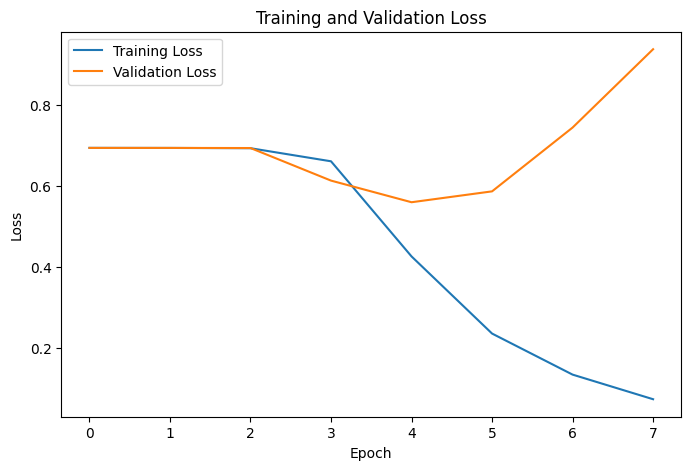

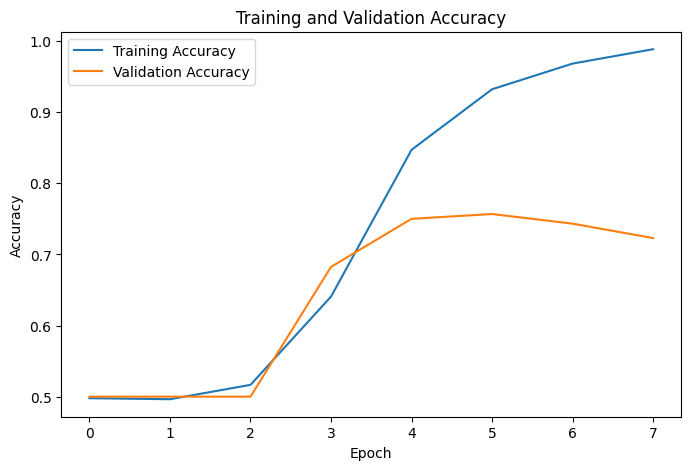

In [25]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Plot training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

D3. Model Training Visualizations

The model training process was visualized using line graphs for loss and accuracy across training epochs. These visualizations were used to evaluate model learning behavior and compare performance on the training and validation data sets.

The loss plot showed that training loss steadily decreased across epochs, indicating that the model improved its fit to the training data over time. Validation loss remained relatively stable early in training, then increased in later epochs while training loss continued to decline. This pattern suggests that the model began to overfit the training data in later epochs.

The accuracy plot showed that training accuracy increased consistently across epochs, while validation accuracy improved more gradually and began to level off near the end of training. Although validation accuracy improved overall, the widening gap between training and validation accuracy further suggests mild overfitting.

Together, these visualizations show that the model successfully learned sentiment patterns in the review data, while also confirming that early stopping was necessary to prevent additional overtraining.


D4. Predictive Accuracy

The predictive accuracy of the trained neural network was evaluated using accuracy, which was selected as the primary evaluation metric for this binary classification task. Accuracy was appropriate because the sentiment classes were balanced, allowing overall prediction performance to be measured reliably.

The model achieved a training accuracy of 83.55%, a validation accuracy of 73.65%, and a test accuracy of 75.84%. The test accuracy is the most important measure of predictive performance because it reflects how well the trained model generalized to unseen review data.

A test accuracy of 75.84% indicates that the model correctly classified customer review sentiment in approximately three out of four unseen cases. This suggests that the neural network was effective at learning sentiment patterns in customer review text and produced useful predictive performance for binary sentiment classification.

Although the model showed some mild overfitting, the final predictive accuracy demonstrates that the network was still able to generalize reasonably well and provide meaningful sentiment predictions on unseen customer reviews.

In [26]:
# E. Save trained neural network
model.save("sentiment_lstm_model.keras")

F. Neural Network Functionality

The neural network was designed to classify customer review text as either positive or negative sentiment. Review text was first converted into numerical sequences through tokenization and padding, then processed through an embedding layer and LSTM layer to learn word relationships and contextual language patterns.

The embedding layer transformed each word into a dense numerical vector, allowing the model to learn semantic relationships between words. The LSTM layer then processed the review as a sequence, allowing the model to capture contextual meaning and word order. This was important for sentiment classification because the meaning of a review often depends on the arrangement of words rather than isolated terms.

After sequence processing, the dense hidden layer learned additional non-linear relationships in the extracted features, while the dropout layer helped reduce overfitting. The final sigmoid output layer produced a binary sentiment prediction indicating whether the review was classified as positive or negative.

Overall, the network architecture was effective for short-text sentiment classification because it allowed the model to learn both semantic and sequential language patterns while maintaining a relatively simple structure appropriate for the size of the data set.


G. Recommendation

Based on the results of this analysis, the recommended course of action is to use the trained neural network as a decision-support tool for automated customer sentiment monitoring.

The model demonstrated that it could classify customer review sentiment with 75.84% accuracy on unseen data, indicating that it can provide useful predictive insight for organizations that process customer feedback at scale. This model could be used to automatically identify negative customer reviews, prioritize customer concerns, and improve response time to customer issues.

Because the model showed mild overfitting, the organization should continue improving performance before full production deployment. Recommended next steps include expanding the training data, testing larger sentiment data sets, and exploring more advanced architectures such as bidirectional LSTM models or pretrained word embeddings.

In its current form, the model is best suited as a practical support tool for identifying customer sentiment trends and helping organizations respond more efficiently to customer feedback.


I. Sources

GeeksforGeeks. (2019, January 16). What is LSTM Long Short Term Memory? GeeksforGeeks. https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/

Kharade, P. A., & Sangam, S. (2025). Sentiment Analysis Employing LSTM for Binary Classification of Social Media Texts. International Journal of Computer Applications, 187(29), 41–48. https://doi.org/10.5120/ijca2025925500

Kotzias, D. (2015). Sentiment Labelled Sentences [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C57604.

Zou, H., & Xiang, K. (2022). Sentiment Classification Method Based on Blending of Emoticons and Short Texts. Entropy, 24(3), 398. https://doi.org/10.3390/e24030398